In [11]:
import pandas as pd
import json

In [2]:
input_path = "../data/arxiv-metadata-oai-snapshot.json"
output_path = "../data/papers_clean.jsonl"

read in chunks → keep wanted columns → keep wanted categories → clean fields → drop bad rows → deduplicate → save clean file

In [ ]:
keep_cols = ["id", "title", "abstract", "authors", "categories", "update_date"]
pattern = r"cs\.LG|cs\.CL|cs\.IR"
#|q-bio\.NC|q-bio\.QM|q-bio\.GN|q-bio\.MN
chunksize = 10000

with open(output_path, "w", encoding="utf-8") as out:
    for chunk in pd.read_json(input_path, lines=True, chunksize=chunksize):
        chunk = chunk[keep_cols].copy()

        chunk["title"] = chunk["title"].fillna("").str.strip()
        chunk["abstract"] = chunk["abstract"].fillna("").str.strip()
        chunk["authors"] = chunk["authors"].fillna("").str.strip()
        chunk["categories"] = chunk["categories"].fillna("").str.strip()
        chunk["update_date"] = chunk["update_date"].fillna("").str.strip()

        chunk = chunk[chunk["categories"].str.contains(pattern, na=False)]
        chunk = chunk[(chunk["title"] != "") & (chunk["abstract"] != "")]
        chunk = chunk[chunk["abstract"].str.len() >= 50]

        chunk = chunk.drop_duplicates(subset=["id"])

        for record in chunk.to_dict(orient="records"):
            out.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Done")

Done


Second deduplication pass on the full cleaned file, because duplicates can appear across different chunks, and drop_duplicates inside a chunk only removes duplicates within that chunk

- Dedup by ID
- Dedup by title & abstract

In [ ]:
input_path = "../data/papers_clean.jsonl"
output_path = "../data/papers_final_cs.jsonl"

In [5]:
df = pd.read_json(input_path, lines=True)

print("Initial rows:", len(df))

df["id"] = df["id"].fillna("").astype(str).str.strip()
df["title"] = df["title"].fillna("").str.strip()
df["abstract"] = df["abstract"].fillna("").str.strip()

df = df.drop_duplicates(subset=["id"])
print("After ID dedup:", len(df))

df = df.drop_duplicates(subset=["title", "abstract"])
print("After title+abstract dedup:", len(df))

with open(output_path, "w", encoding="utf-8") as f:
    for record in df.to_dict(orient="records"):
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Saved final file to {output_path}")

Initial rows: 375714
After ID dedup: 375714
After title+abstract dedup: 375672
Saved final file to ../data/papers_final.jsonl


Check

In [6]:
df_final = pd.read_json("../data/papers_final.jsonl", lines=True)

print(df_final.shape)
print(df_final[["id", "title", "categories"]].head())

(375672, 6)
         id                                              title  \
0  704.0021  Molecular Synchronization Waves in Arrays of A...   
1  704.0036  A remark on the number of steady states in a m...   
2  704.0392  Simulation of Robustness against Lesions of Co...   
3  704.0634  A Finite Element framework for computation of ...   
4  704.0648  Behavioral response to strong aversive stimuli...   

                                categories  
0         nlin.PS physics.chem-ph q-bio.MN  
1                        q-bio.QM q-bio.MN  
2  q-bio.NC cond-mat.dis-nn physics.soc-ph  
3                        q-bio.BM q-bio.QM  
4                                 q-bio.NC  


year
2007     2256
2008     1244
2009     1336
2010      893
2011     1087
2012     2212
2013     2659
2014     3123
2015     4719
2016     6300
2017     8015
2018    12923
2019    21095
2020    29552
2021    34072
2022    36880
2023    43764
2024    57029
2025    77253
2026    29260

Total: 375,672 papers
2019+: 328,905 papers (87.6%)


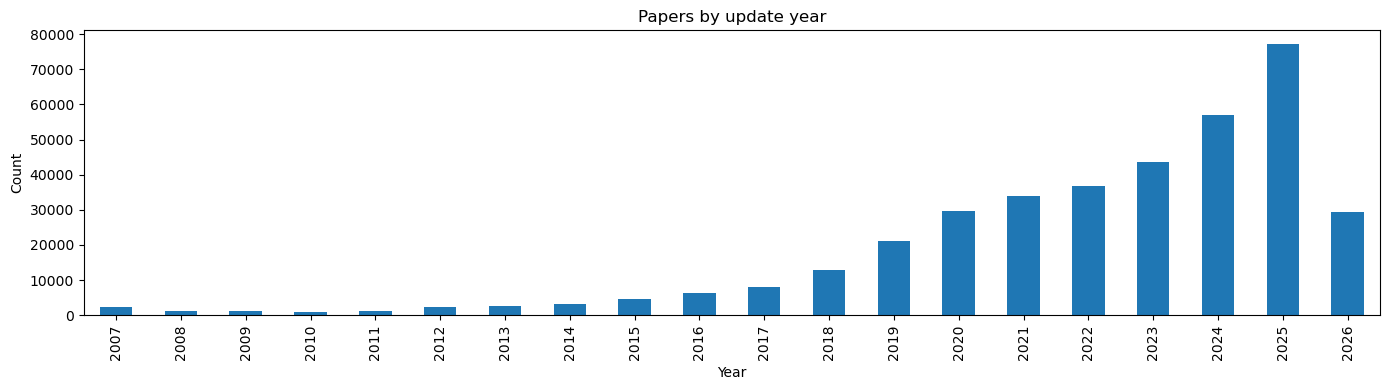

In [7]:
import matplotlib.pyplot as plt

df_final["update_date"] = pd.to_datetime(df_final["update_date"], errors="coerce")
df_final["year"] = df_final["update_date"].dt.year

year_counts = df_final["year"].value_counts().sort_index()
print(year_counts.to_string())
print(f"\nTotal: {len(df_final):,} papers")
print(f"2019+: {(df_final['year'] >= 2019).sum():,} papers ({(df_final['year'] >= 2019).mean():.1%})")

year_counts.plot(kind="bar", figsize=(14, 4), title="Papers by update year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Filter to `papers_filtered.jsonl`: cs.CL / cs.IR / cs.LG · abstract ≥ 150 chars · date ≥ cutoff year · global dedup

In [16]:
df_src = pd.read_json("../data/papers_final.jsonl", lines=True)
print(f"Loaded: {len(df_src):,}")

# Category filter
cat_pattern = r"cs\.CL|cs\.IR"
df_src = df_src[df_src["categories"].str.contains(cat_pattern, na=False)]
print(f"After category filter (cs.CL/IR): {len(df_src):,}")

# Abstract length
df_src = df_src[df_src["abstract"].str.len() >= 150]
print(f"After abstract >= 150 chars: {len(df_src):,}")

# Global dedup
df_src = df_src.drop_duplicates(subset=["id"])
df_src = df_src.drop_duplicates(subset=["title", "abstract"])
print(f"After global dedup: {len(df_src):,}")

# Date cutoff comparison
df_src["update_date"] = pd.to_datetime(df_src["update_date"], errors="coerce")
df_src["year"] = df_src["update_date"].dt.year

for cutoff in [2018, 2020]:
    n = (df_src["year"] >= cutoff).sum()
    print(f"  >= {cutoff}: {n:,} papers ({n/len(df_src):.1%})")

Loaded: 375,672
After category filter (cs.CL/IR): 123,579
After abstract >= 150 chars: 123,537
After global dedup: 123,537
  >= 2018: 113,377 papers (91.8%)
  >= 2020: 103,260 papers (83.6%)


In [17]:
YEAR_CUTOFF = 2020  # change to 2018 if preferred

df_filtered = df_src[df_src["year"] >= YEAR_CUTOFF].drop(columns=["year"]).copy()
df_filtered["update_date"] = df_filtered["update_date"].dt.strftime("%Y-%m-%d")

output_path = "../data/papers_filtered.jsonl"
with open(output_path, "w", encoding="utf-8") as f:
    for record in df_filtered.to_dict(orient="records"):
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Saved {len(df_filtered):,} papers to {output_path}")

Saved 103,260 papers to ../data/papers_filtered.jsonl
